# *Sample Solution* — Exercise 1: Fully Connected and Convolutional Neural Networks


---

**Note**: For this assignment, it is **highly recommended that you use a GPU** to speed up the training process, especially for the convolutional neural network (CNN) model. Training on a CPU can be significantly slower, particularly for models with many parameters. If you don't have access to a GPU, you can use free resources like Kaggle Notebooks or Google Colab, which  offer free GPU support.





## 1. Load and Explore the MNIST Dataset



### 1.1 Import Libraries

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers

import matplotlib.pyplot as plt

### 1.2 Load Dataset

Load the MNIST dataset, a collection of 28x28 grayscale images representing handwritten digits from 0 to 9, using [TensorFlow's `datasets` module](https://www.tensorflow.org/datasets). Visualize the dataset by displaying a grid of 16 randomly selected images along with their labels.

In [ ]:
# load MNIST dataset from TensorFlow
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


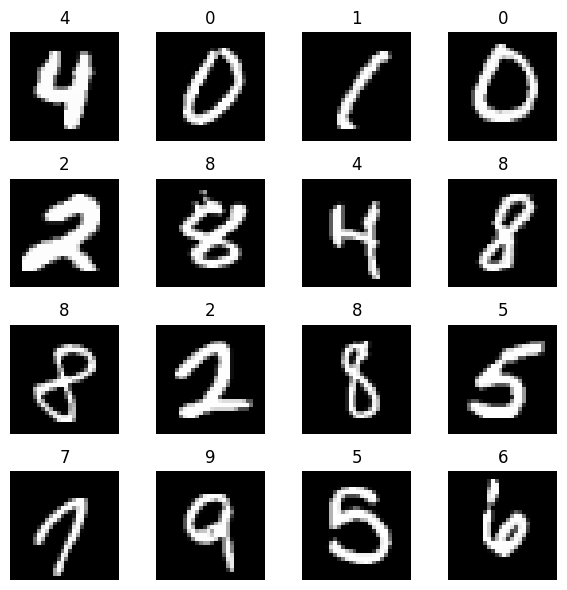

In [ ]:
# visualize 16 randomly selected images along with their labels
ds_visual = ds_train.shuffle(10000).take(16)

plt.figure(figsize=(6,6))
for i, (image, label) in enumerate(ds_visual):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(str(label.numpy()))
    plt.axis('off')

plt.tight_layout()
plt.show()

### 1.3 Data Preprocessing

Preprocess the data by normalizing the pixel values to the range [0, 1].

In [ ]:
# normalize the pixel values to the range [0, 1]
def normalize_img(image, label):
    # convert from uint8 to float32 and normalize to [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(normalize_img)
ds_test = ds_test.map(normalize_img)

## 2. Define and Train a Fully Connected Neural Network (FCN)

Using [TensorFlow's keras API](https://keras.io/api/), define a fully connected neural network (FCN) with the following architecture:

* **Input Layer**: A flattened version of the 28x28 input images (i.e., shape (784,)).
* **Hidden Layers**: Two dense layers, each with 128 neurons and ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (one per digit) and softmax activation for classification.

Train the model using the Adam optimizer with a learning rate of 0.001, cross-entropy loss, and track accuracy. Train for 10 epochs with a batch size of 32. Evaluate the test accuracy and analyze the training process using the learning curves (loss and accuracy).




In [ ]:
# define model layer-by-layer using TensorFlow/keras
fcn_model = keras.Sequential([
    layers.Input((28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

fcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fcn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the model

num_examples = ds_info.splits['train'].num_examples
# shuffle and batch the training dataset
ds_train = ds_train.shuffle(num_examples).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
# batch the test dataset
ds_test = ds_test.batch(32).prefetch(tf.data.experimental.AUTOTUNE)

history_fcn = fcn_model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8858 - loss: 0.3971 - val_accuracy: 0.9593 - val_loss: 0.1225
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9676 - loss: 0.1036 - val_accuracy: 0.9682 - val_loss: 0.1004
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9786 - loss: 0.0690 - val_accuracy: 0.9713 - val_loss: 0.0949
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9843 - loss: 0.0497 - val_accuracy: 0.9750 - val_loss: 0.0792
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9877 - loss: 0.0394 - val_accuracy: 0.9795 - val_loss: 0.0729
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9904 - loss: 0.0290 - val_accuracy: 0.9792 - val_loss: 0.0691
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9919 - loss: 0.0265 - val_accuracy: 0.9775 - val_loss: 0.0796
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9925 - loss: 0.0216

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 0.0976
Test accuracy: 0.9745000004768372


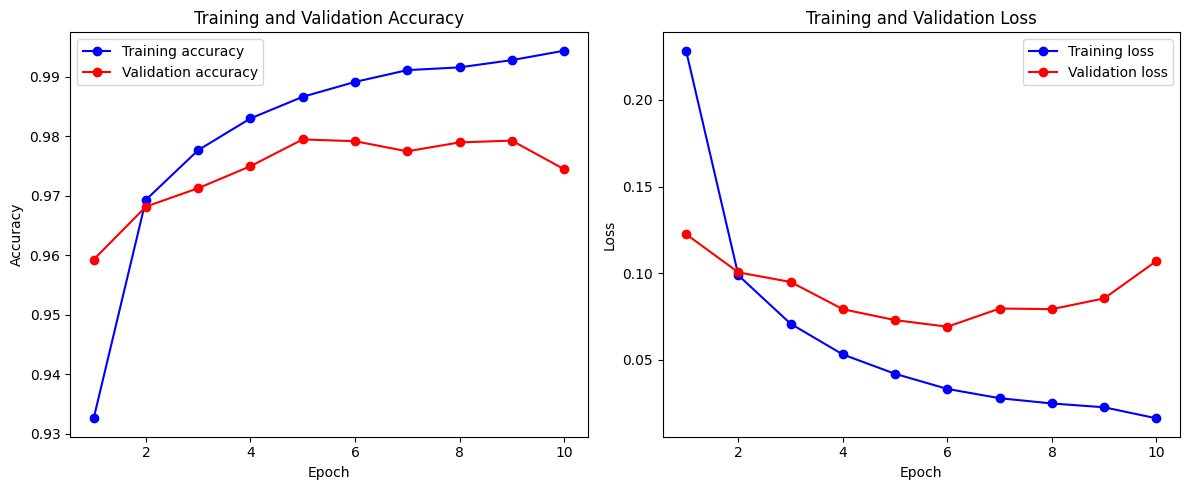

In [ ]:
# evaluate the model
test_loss, test_accuracy = fcn_model.evaluate(ds_test)
print("Test accuracy:", test_accuracy)

# extract values for plotting
acc = history_fcn.history['accuracy']
val_acc = history_fcn.history['val_accuracy']
loss = history_fcn.history['loss']
val_loss = history_fcn.history['val_loss']
epochs = range(1, len(acc) + 1)

# plot training & validation accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# plot training & validation loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Define and Train a Convolutional Neural Network (CNN)

Create a convolutional neural network (CNN) for MNIST classification using TensorFlow's keras API with the following architecture:

* **Input Layer**: Accepts 28x28 grayscale images with shape (28, 28, 1).
* **Conv2D Layer 1**: 32 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2) for spatial down-sampling.
* **Conv2D Layer 2**: 64 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2).
* **Flatten Layer**: Converts the 2D feature map into a 1D vector.
* **Dense Layer**: 128 neurons with ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (softmax activation).

Train this CNN using the same setup as in Task 2. Adjust the learning rate, epoch count, and batch size if necessary. After training, compare its test accuracy and training process to the FCN from Task 2.

In [ ]:
# define model layer-by-layer using TensorFlow/keras
cnn_model = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the model
history_cnn = cnn_model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9066 - loss: 0.3010 - val_accuracy: 0.9861 - val_loss: 0.0436
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9877 - val_loss: 0.0365
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9916 - loss: 0.0283 - val_accuracy: 0.9871 - val_loss: 0.0409
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9874 - val_loss: 0.0397
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9955 - loss: 0.0145 - val_accuracy: 0.9906 - val_loss: 0.0311
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9901 - val_loss: 0.0370
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.9913 - val_loss: 0.0322
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9981 - loss: 0.0060

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0410
CNN Test accuracy: 0.9911999702453613


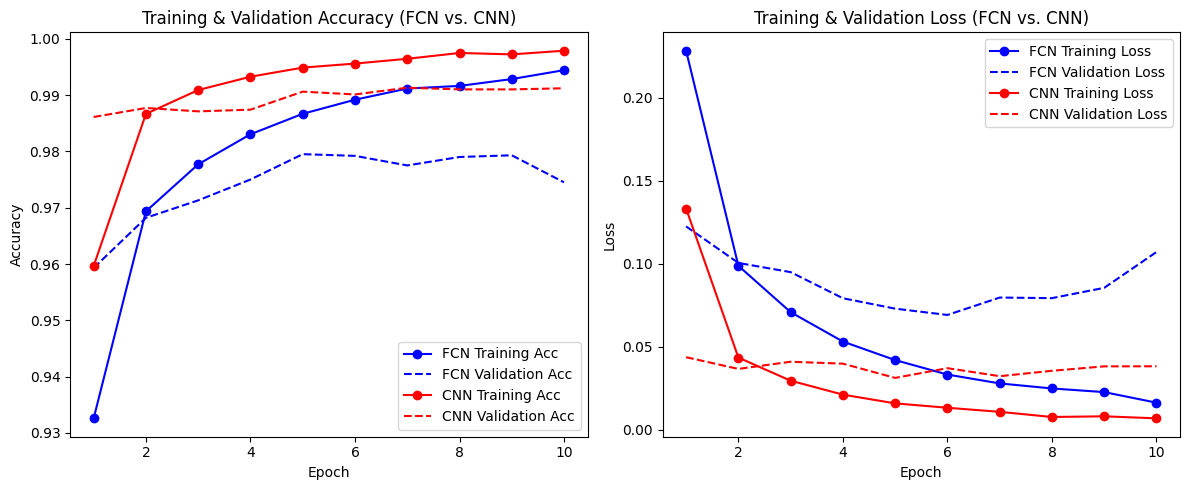

In [ ]:
# evaluate the model and compare it to the FCN from task 2
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(ds_test)
print("CNN Test accuracy:", test_accuracy_cnn)

# extract FCN history metrics
fcn_acc = history_fcn.history['accuracy']
fcn_val_acc = history_fcn.history['val_accuracy']
fcn_loss = history_fcn.history['loss']
fcn_val_loss = history_fcn.history['val_loss']

# extract CNN history metrics
cnn_acc = history_cnn.history['accuracy']
cnn_val_acc = history_cnn.history['val_accuracy']
cnn_loss = history_cnn.history['loss']
cnn_val_loss = history_cnn.history['val_loss']

epochs = range(1, len(fcn_acc) + 1)

plt.figure(figsize=(12,5))

# plot accuracy comparison
plt.subplot(1,2,1)
plt.plot(epochs, fcn_acc, 'bo-', label='FCN Training Acc')
plt.plot(epochs, fcn_val_acc, 'b--', label='FCN Validation Acc')
plt.plot(epochs, cnn_acc, 'ro-', label='CNN Training Acc')
plt.plot(epochs, cnn_val_acc, 'r--', label='CNN Validation Acc')
plt.title('Training & Validation Accuracy (FCN vs. CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# plot loss comparison
plt.subplot(1,2,2)
plt.plot(epochs, fcn_loss, 'bo-', label='FCN Training Loss')
plt.plot(epochs, fcn_val_loss, 'b--', label='FCN Validation Loss')
plt.plot(epochs, cnn_loss, 'ro-', label='CNN Training Loss')
plt.plot(epochs, cnn_val_loss, 'r--', label='CNN Validation Loss')
plt.title('Training & Validation Loss (FCN vs. CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()